<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/credit_information_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np


def scratch_train_test_split(X, y, train_size=0.8, random_state=0):
    if X.shape[0] != y.shape[0]:
        raise ValueError("X and y must contain the same number of samples")
    if not 0 < train_size < 1:
        raise ValueError("train_size must be between 0 and 1")

    rng = np.random.default_rng(random_state)
    indices = rng.permutation(X.shape[0])
    n_train = int(np.floor(X.shape[0] * train_size))

    train_indices = indices[:n_train]
    test_indices = indices[n_train:]

    return (
        X[train_indices],
        X[test_indices],
        y[train_indices],
        y[test_indices],
    )

In [2]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = scratch_train_test_split(X, y)

print("X:", X.shape)
print("y:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X: (150, 4)
y: (150,)
X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


In [3]:
from sklearn.datasets import load_iris

X_all, y_all = load_iris(return_X_y=True)
mask = y_all != 0
X = X_all[mask]
y = y_all[mask] - 1

X_train, X_test, y_train, y_test = scratch_train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
)

In [4]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

models = {
    "logistic regression": make_pipeline(
        StandardScaler(),
        SGDClassifier(loss="log_loss", random_state=0),
    ),
    "SVM": make_pipeline(
        StandardScaler(),
        SVC(gamma="scale"),
    ),
}

In [5]:
from sklearn.tree import DecisionTreeClassifier

models["decision tree"] = DecisionTreeClassifier(random_state=0)

In [6]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("  accuracy:", accuracy_score(y_test, y_pred))
    print("  precision:", precision_score(y_test, y_pred, zero_division=0))
    print("  recall:", recall_score(y_test, y_pred, zero_division=0))
    print("  F1:", f1_score(y_test, y_pred, zero_division=0))

logistic regression
  accuracy: 0.7
  precision: 0.8888888888888888
  recall: 0.6153846153846154
  F1: 0.7272727272727273
SVM
  accuracy: 0.85
  precision: 0.9166666666666666
  recall: 0.8461538461538461
  F1: 0.88
decision tree
  accuracy: 0.65
  precision: 0.875
  recall: 0.5384615384615384
  F1: 0.6666666666666666


In [1]:
import pandas as pd

data = pd.read_csv("train.csv")
X = data[["GrLivArea", "YearBuilt"]].to_numpy()
y = data["SalePrice"].to_numpy()

X_train, X_test, y_train, y_test = scratch_train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [2]:
import pandas as pd

data = pd.read_csv("train.csv")
X = data[["GrLivArea", "YearBuilt"]].to_numpy()
y = data["SalePrice"].to_numpy()

X_train, X_test, y_train, y_test = scratch_train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [3]:
import os

print(os.getcwd())

/content


In [4]:
print(os.listdir())

['.config', 'sample_data']


In [5]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [6]:
import pandas as pd

data = pd.read_csv("train.csv")

X = data[["GrLivArea", "YearBuilt"]].to_numpy()
y = data["SalePrice"].to_numpy()

In [7]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(
    y_train.reshape(-1, 1)
).ravel()

NameError: name 'X_train' is not defined

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=123
)

In [9]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

In [10]:
import pandas as pd

data = pd.read_csv("train.csv")

X = data[["GrLivArea", "YearBuilt"]].to_numpy()
y = data["SalePrice"].to_numpy()

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

In [12]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

In [13]:
from sklearn.linear_model import SGDRegressor

model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=0)
model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = model.predict(X_test_scaled)
y_pred = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).ravel()

NameError: name 'y_train_scaled' is not defined

In [14]:
model.fit(X_train_scaled, y_train_scaled)

NameError: name 'y_train_scaled' is not defined

In [15]:
import numpy as np


class ScratchLinearRegression:
    def __init__(self, num_iter, lr, no_bias, verbose):
        self.iter = num_iter
        self.lr = lr
        self.no_bias = no_bias
        self.verbose = verbose
        self.theta = np.array([])
        self.loss = np.zeros(num_iter)
        self.val_loss = np.zeros(num_iter)

    def fit(self, X, y, X_val=None, y_val=None):
        """Train the linear regression model."""
        pass

    def _linear_hypothesis(self, X):
        """Calculate predictions from the current parameters."""
        pass

    def _gradient_descent(self, X, error):
        """Update the parameters by gradient descent."""
        pass

    def predict(self, X):
        """Return predictions for the given features."""
        pass

In [ ]:
### 1. What kind of company is Home Credit?

Home Credit is a financial services company that provides loans and
financing, particularly to people who may have limited access to
traditional banking services.

The company uses customer information to assess credit risk and make
lending decisions.

In [ ]:
### 2. What prediction is required?

The competition aims to predict whether a loan applicant is likely to
experience repayment difficulties.

The target variable is `TARGET`.

- `TARGET = 0`: the client did not have significant repayment difficulties.
- `TARGET = 1`: the client experienced repayment difficulties.

Therefore, this is a binary classification problem.

The model should estimate the probability that a client will have
repayment difficulties.

In [ ]:
### 3. Benefits and Risks

#### Benefits

Predicting credit risk can help financial institutions:

- make faster and more consistent lending decisions;
- identify applicants who may have difficulty repaying a loan;
- reduce financial losses caused by loan defaults;
- potentially provide credit to customers who may otherwise have limited
  access to financial services.

#### Risks

There are also important risks:

- personal and financial information may be sensitive;
- biased data can lead to unfair predictions;
- some variables may indirectly represent protected characteristics;
- incorrect predictions can negatively affect people's access to credit;
- a statistical prediction does not necessarily represent a causal
  relationship.

Therefore, a credit risk model should be evaluated not only for
predictive performance but also for fairness, privacy, transparency,
and potential discrimination.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving application_train.csv.zip to application_train.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile("application_train.csv.zip", "r") as zip_ref:
    zip_ref.extractall("application train")

In [3]:
import pandas as pd

df = pd.read_csv("application train/application_train.csv")

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.shape

(307511, 122)

In [5]:
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [6]:
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [7]:
df["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [10]:
import os

os.listdir()

['.config', 'application train', 'application_train.csv.zip', 'sample_data']

In [13]:
description = pd.read_csv(
    "HomeCredit_columns_description.csv",
    encoding="latin1"
)

description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [14]:
description = pd.read_csv(
    "HomeCredit_columns_description.csv",
    encoding="latin1"
)

description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [15]:
description.columns

Index(['Unnamed: 0', 'Table', 'Row', 'Description', 'Special'], dtype='object')

In [16]:
description[description["Row"].astype(str).str.contains("TARGET", case=False, na=False)]

,Unnamed: 0,Table,Row,Description,Special
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN


In [17]:
df["TARGET"].value_counts()

,count
TARGET,
0,282686
1,24825


In [18]:
df["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


In [19]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
### 1. First Look at the Dataset

The `head()` method displays the first five rows of the dataset.
It provides an initial overview of the variables and their values.

The dataset contains information about loan applicants, including
demographic, financial, employment, and credit-related variables.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
### 2. Dataset Information

The `info()` method provides information about the structure of the
dataset.

The dataset contains both numerical and categorical variables.
Some columns contain missing values, which will need to be considered
during the data analysis.

The dataset also contains a mixture of integer, floating-point, and
object variables.

In [21]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [22]:
df.describe(include="all")

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511,307511,307511,307511,307511.000000,3.075110e+05,3.075110e+05,307499.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
unique,NaN,NaN,2,3,2,2,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Cash loans,F,N,Y,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,278232,202448,202924,213312,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,278180.518577,0.080729,NaN,NaN,NaN,NaN,0.417052,1.687979e+05,5.990260e+05,27108.573909,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,NaN,NaN,NaN,NaN,0.722121,2.371231e+05,4.024908e+05,14493.737315,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,2.565000e+04,4.500000e+04,1615.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.125000e+05,2.700000e+05,16524.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,1.471500e+05,5.135310e+05,24903.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,NaN,NaN,NaN,NaN,1.000000,2.025000e+05,8.086500e+05,34596.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000


In [ ]:
### 3. Statistical Summary

The `describe()` method provides descriptive statistics for the
numerical variables, including the count, mean, standard deviation,
minimum, quartiles, and maximum.

These statistics help identify the scale and distribution of the
variables and can also help detect potential outliers.

In [23]:
missing_count = df.isnull().sum()

missing_count.sort_values(ascending=False).head(20)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


In [24]:
missing_percentage = (df.isnull().mean() * 100)

missing_percentage = missing_percentage.sort_values(ascending=False)

missing_percentage.head(20)

,0
COMMONAREA_AVG,69.872297
COMMONAREA_MODE,69.872297
COMMONAREA_MEDI,69.872297
NONLIVINGAPARTMENTS_MEDI,69.432963
NONLIVINGAPARTMENTS_MODE,69.432963
NONLIVINGAPARTMENTS_AVG,69.432963
FONDKAPREMONT_MODE,68.386172
LIVINGAPARTMENTS_AVG,68.354953
LIVINGAPARTMENTS_MEDI,68.354953
LIVINGAPARTMENTS_MODE,68.354953


In [25]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_table = missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table.head(20)

,Missing Values,Missing Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [ ]:
### 4. Missing Values

The dataset contains missing values in several columns.

The number and percentage of missing values were calculated for each
feature. Some variables have only a small number of missing values,
while others have a much larger proportion.

Missing values are important because they can affect statistical
analysis and machine learning models. The appropriate treatment will
depend on the type of variable and the proportion of missing values.

At this stage, the original data is kept unchanged. Missing values will
be handled later if necessary.

In [26]:
target_counts = df["TARGET"].value_counts()

target_counts

,count
TARGET,
0,282686
1,24825


In [27]:
target_percentages = df["TARGET"].value_counts(normalize=True) * 100

target_percentages

,proportion
TARGET,
0,91.927118
1,8.072882


In [28]:
target_summary = pd.DataFrame({
    "Count": df["TARGET"].value_counts(),
    "Percentage": df["TARGET"].value_counts(normalize=True) * 100
})

target_summary

,Count,Percentage
TARGET,,
0,282686,91.927118
1,24825,8.072882


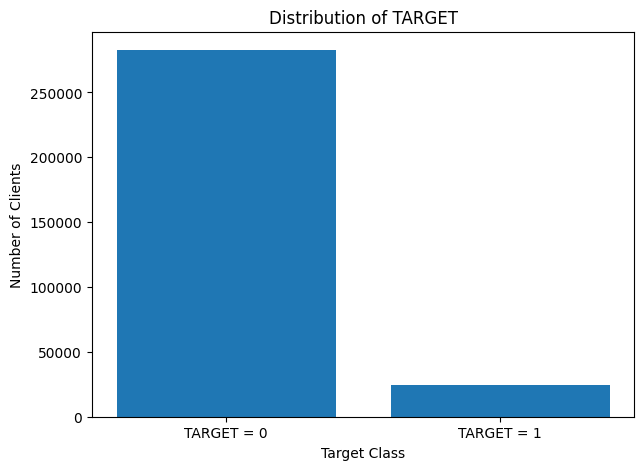

In [29]:
import matplotlib.pyplot as plt

target_counts = df["TARGET"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["TARGET = 0", "TARGET = 1"],
    target_counts.values
)

plt.xlabel("Target Class")
plt.ylabel("Number of Clients")
plt.title("Distribution of TARGET")

plt.show()

In [ ]:
### 5. Target Distribution

The target variable is highly imbalanced.

`TARGET = 0` represents approximately 91.93% of the observations,
while `TARGET = 1` represents approximately 8.07%.

Therefore, the majority class is `TARGET = 0`, while `TARGET = 1`
is the minority class.

This class imbalance is important for the analysis because accuracy
alone may not be an appropriate measure of model performance. A model
could achieve high accuracy simply by predicting the majority class
for most observations.

For this reason, additional evaluation metrics should be considered
when building a predictive model.

In [ ]:
## Problem 3 — Defining the Analysis Questions

Based on the initial exploration of the dataset, several analysis
questions can be formulated.

### Question 1 — Income and repayment difficulties

Is there a relationship between `AMT_INCOME_TOTAL` and `TARGET`?

We can compare the income distribution of clients with `TARGET = 0`
and `TARGET = 1`. This could help us understand whether income level
is associated with repayment difficulties.

### Question 2 — Credit amount and repayment difficulties

Is `AMT_CREDIT` associated with `TARGET`?

Comparing the credit amounts between the two target groups may help
identify whether clients receiving larger loans have different
repayment outcomes.

### Question 3 — Age and repayment difficulties

Is the age of the applicant associated with `TARGET`?

The variables `DAYS_BIRTH` and `TARGET` can be examined to compare the
age distribution of clients with and without repayment difficulties.

### Question 4 — Employment history

Is employment duration associated with repayment difficulties?

The variables `DAYS_EMPLOYED` and `TARGET` can be analyzed to determine
whether employment history differs between the two target groups.

### Question 5 — Education level

Is `NAME_EDUCATION_TYPE` associated with `TARGET`?

Comparing repayment outcomes across education categories may help us
understand whether the target distribution differs between groups.

### Question 6 — Loan affordability

Is the relationship between income and credit amount associated with
repayment difficulties?

We can compare `AMT_CREDIT` relative to `AMT_INCOME_TOTAL` between the
two target groups. This may provide information about the relationship
between loan size and applicant income.

### Important limitation

These questions investigate statistical associations in the dataset.
A correlation or association does not prove causation.

In addition, differences between demographic or socioeconomic groups
should not automatically be interpreted as evidence of unfairness or
discrimination. Credit-related data can contain sensitive information,
so the analysis should avoid exposing individual personal information
and should be interpreted carefully.

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

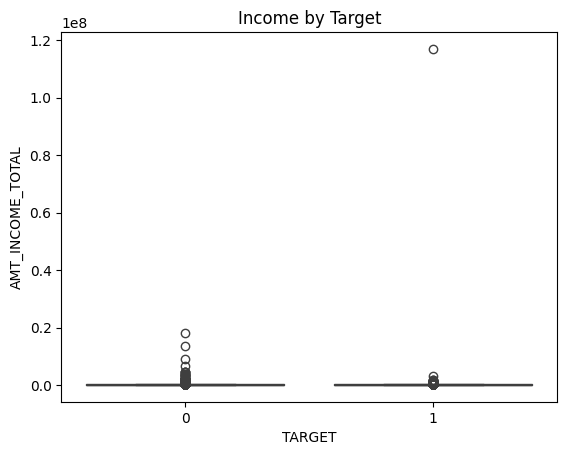

In [32]:
sns.boxplot(data=df, x="TARGET", y="AMT_INCOME_TOTAL")
plt.title("Income by Target")
plt.show()

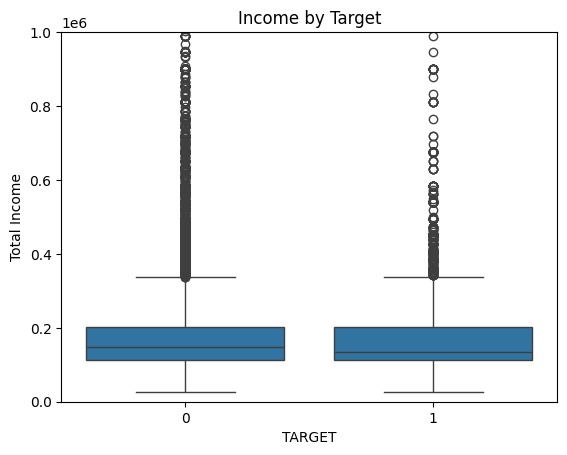

In [38]:
sns.boxplot(data=df, x="TARGET", y="AMT_INCOME_TOTAL")

plt.ylim(0, 1000000)
plt.xlabel("TARGET")
plt.ylabel("Total Income")
plt.title("Income by Target")
plt.show()

In [ ]:
### Income by Target

The boxplot compares the total income (`AMT_INCOME_TOTAL`) of clients
with `TARGET = 0` and `TARGET = 1`.

The median income appears to be relatively similar between the two
groups, although the distributions contain many extreme values.

The denominator is the number of clients in each target group with
available income information.

This graph suggests that income alone may not clearly distinguish
clients with and without repayment difficulties. The extreme values
also make the distribution difficult to compare visually.

This is an association only and does not mean that income causes
repayment difficulties.

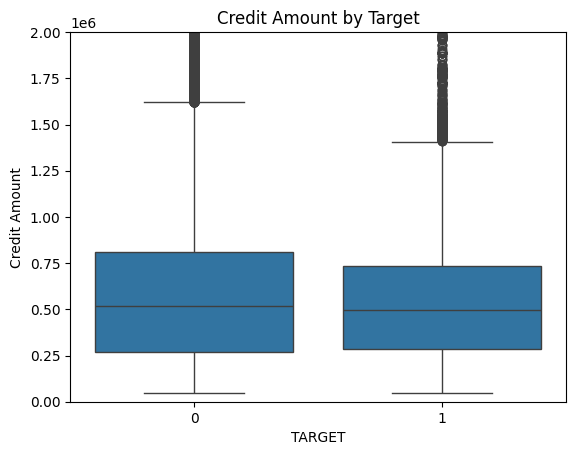

In [33]:
sns.boxplot(data=df, x="TARGET", y="AMT_CREDIT")

plt.ylim(0, 2000000)
plt.xlabel("TARGET")
plt.ylabel("Credit Amount")
plt.title("Credit Amount by Target")

plt.show()

In [ ]:
### Credit Amount by Target

The credit amount is compared between the two target classes.
The denominator is the number of clients in each target group.
Extreme values may affect the visualization.

In [34]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25

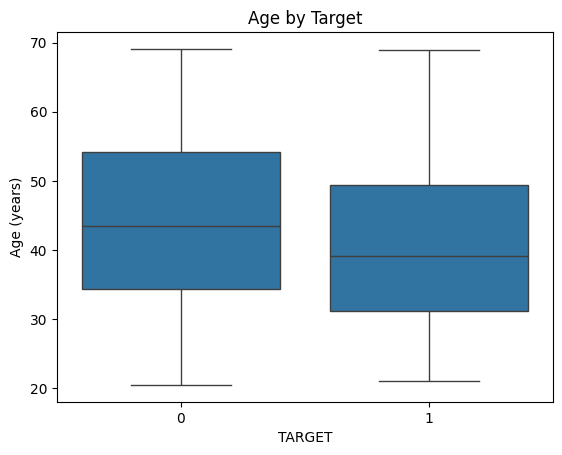

In [35]:
sns.boxplot(data=df, x="TARGET", y="AGE_YEARS")

plt.xlabel("TARGET")
plt.ylabel("Age (years)")
plt.title("Age by Target")

plt.show()

In [ ]:
### Age by Target

The age distribution is compared between the two target classes.
The denominator is the number of clients with available age information.
The result shows an association, not causation.

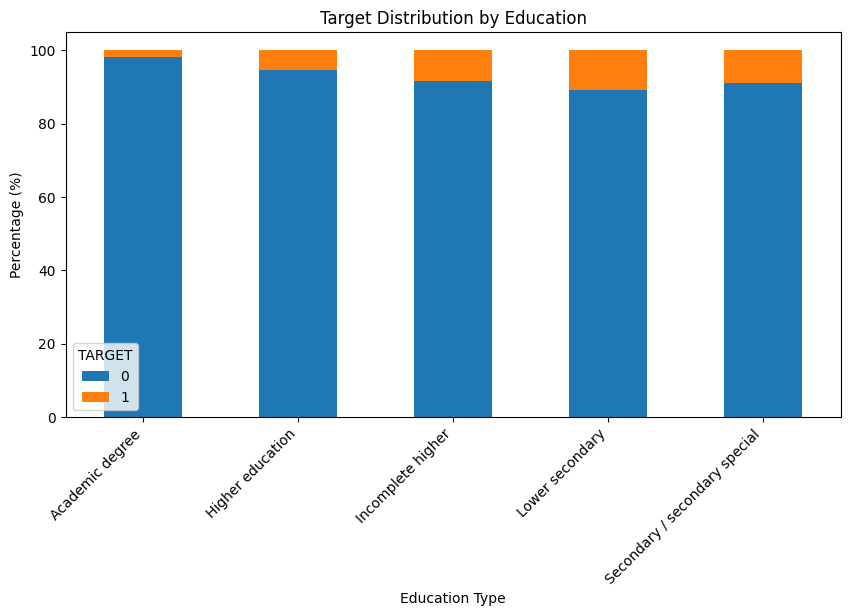

In [36]:
education_target = pd.crosstab(
    df["NAME_EDUCATION_TYPE"],
    df["TARGET"],
    normalize="index"
) * 100

education_target.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel("Education Type")
plt.ylabel("Percentage (%)")
plt.title("Target Distribution by Education")
plt.xticks(rotation=45, ha="right")
plt.show()

In [ ]:
### Education by Target

The chart shows the percentage of each target class within each
education category.

The denominator is the total number of clients in each education
category.

Some categories have fewer observations, which can make their
percentages less reliable.

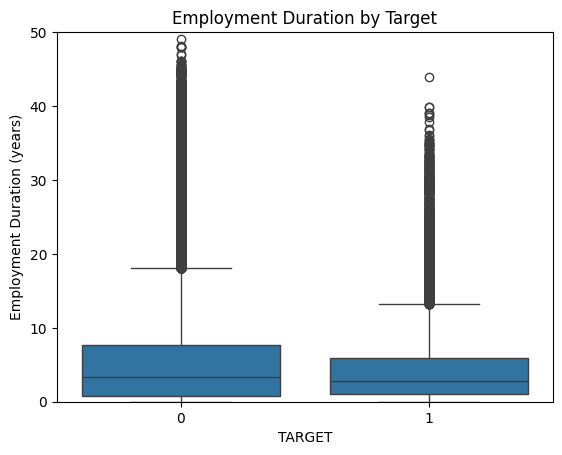

In [37]:
df["EMPLOYED_YEARS"] = -df["DAYS_EMPLOYED"] / 365.25

sns.boxplot(
    data=df,
    x="TARGET",
    y="EMPLOYED_YEARS"
)

plt.ylim(0, 50)
plt.xlabel("TARGET")
plt.ylabel("Employment Duration (years)")
plt.title("Employment Duration by Target")

plt.show()

In [ ]:
### Employment Duration by Target

The employment duration is compared between the two target classes.

The denominator is the number of clients with available employment
information.

Special values in `DAYS_EMPLOYED` may affect the result.

In [ ]:
### Conclusion

The five analyses show differences in income, credit amount, age,
education, and employment duration between the two target groups.

These results show associations, but they do not prove causality.